# Project Title & Objective

## **Breast Ultrasound Image Classification using CNNs**

This project aims to classify breast ultrasound images into three categories: **Benign**, **Malignant**, and **Normal**. We use transfer learning on top-performing CNN models like ResNet50, DenseNet121, InceptionV3, and EfficientNetB0. Additionally, performance analysis, visualizations, and evaluation metrics are incorporated to make this notebook comprehensive and presentation-ready.

# 1. Importing Libraries & Setup

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import cv2
import os
import shutil
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Activation, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# 2. Data Preparation





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Breast_cancer_assets/Dataset_BUSI_with_GT'

Mounted at /content/drive


# 3. Loading and Organizing the Data

In [ ]:
filepaths = []
labels = []

folds = os.listdir(DATASET_PATH)
for fold in folds:
    fold_path = os.path.join(DATASET_PATH, fold)
    filelists = os.listdir(fold_path)
    for file in filelists:
        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        filepaths.append(os.path.join(fold_path, file))
        labels.append(fold)

df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})

print("\nSample Data:")
display(df.head())
print(f"\nTotal images: {len(df)}")



Sample Data:


,filepaths,labels
0,/content/drive/MyDrive/Breast_cancer_assets/Da...,normal
1,/content/drive/MyDrive/Breast_cancer_assets/Da...,normal
2,/content/drive/MyDrive/Breast_cancer_assets/Da...,normal
3,/content/drive/MyDrive/Breast_cancer_assets/Da...,normal
4,/content/drive/MyDrive/Breast_cancer_assets/Da...,normal



Total images: 1578


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('filepaths').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

# 4. Data Visualization

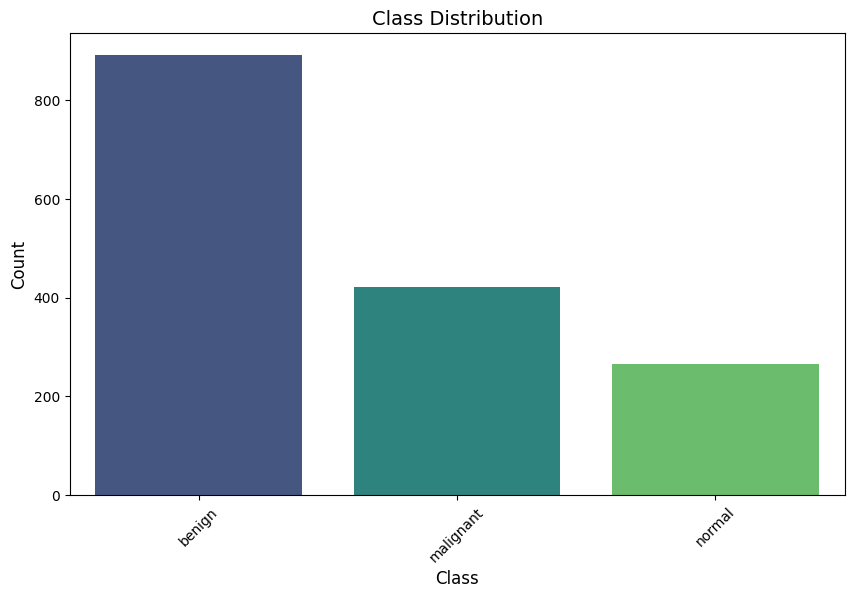

In [ ]:
plt.figure(figsize=(10, 6))
class_dist = df['labels'].value_counts()
sns.barplot(x=class_dist.index, y=class_dist.values, palette='viridis')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()


# 5. Data Splitting

In [ ]:
train_df, test_df = train_test_split(df, train_size=0.8, stratify=df['labels'], random_state=42)
valid_df, test_df = train_test_split(test_df, train_size=0.5, stratify=test_df['labels'], random_state=42)

print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")



Training samples: 1262
Validation samples: 158
Test samples: 158


# 6. Image Preprocessing and Augmentation
We'll use ImageDataGenerator to preprocess images and apply data augmentation

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

def create_generators(train_df, valid_df, test_df):
    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepaths',
        y_col='labels',
        target_size=img_size,
        batch_size=batch_size,
        color_mode='rgb',
        class_mode='categorical',
        shuffle=True
    )

    valid_gen = test_datagen.flow_from_dataframe(
        valid_df,
        x_col='filepaths',
        y_col='labels',
        target_size=img_size,
        batch_size=batch_size,
        color_mode='rgb',
        class_mode='categorical',
        shuffle=False
    )

    test_gen = test_datagen.flow_from_dataframe(
        test_df,
        x_col='filepaths',
        y_col='labels',
        target_size=img_size,
        batch_size=batch_size,
        color_mode='rgb',
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, valid_gen, test_gen

train_gen, valid_gen, test_gen = create_generators(train_df, valid_df, test_df)
class_names = list(train_gen.class_indices.keys())
num_classes = len(class_names)

Found 1262 validated image filenames belonging to 3 classes.
Found 158 validated image filenames belonging to 3 classes.
Found 158 validated image filenames belonging to 3 classes.


# 7. Visualizing Sample Images
Let's look at some sample images from our training set to understand what our model will be learning from.

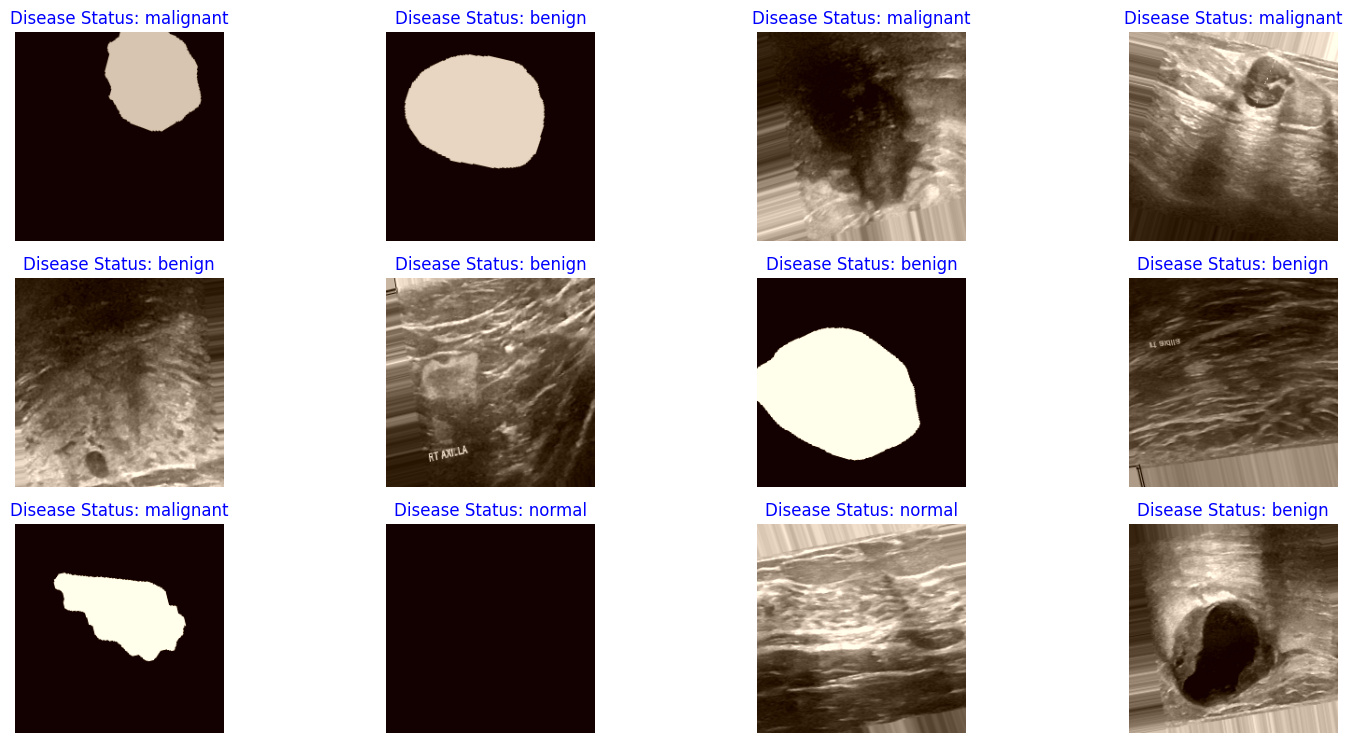

In [ ]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())

images, labels = next(train_gen)

plt.figure(figsize=(15, 10))
for i in range(12):
    plt.subplot(4, 4, i + 1)
    mean = [123.68, 116.779, 103.939]
    img = images[i] + mean
    img = np.clip(img, 0, 255).astype('uint8')
    plt.imshow(img)
    plt.title(f'Disease Status: {classes[labels[i].argmax()]}', color='blue', fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 8. Model Directory Setup




In [ ]:
MODEL_DIR = '/content/drive/MyDrive/Breast_Cancer_Models'
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

epochs = 20
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 8.1 Simple CNN Model

In [ ]:
def build_cnn_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

    return model

cnn_model = build_cnn_model()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

# 8.2 VGG16 Model

In [ ]:
def build_vgg_model():
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(img_size[0], img_size[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adamax(learning_rate=0.0005),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

    return model

vgg_model = build_vgg_model()
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# 8.3 ResNet50 Model

In [ ]:
def build_resnet_model():
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(img_size[0], img_size[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

    return model

resnet_model = build_resnet_model()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# 8.4 InceptionV3 (GoogleNet)

In [ ]:
def build_inception_model():
    base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(img_size[0], img_size[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

    return model

inception_model = build_inception_model()
inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 111, 111,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,328,099 (85.17 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

# 8.5 SE-ResNet Model

In [ ]:
from tensorflow.keras.layers import Multiply

def se_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]

    # Squeeze
    se = GlobalAveragePooling2D()(input_tensor)
    # Excitation
    se = Dense(channels // ratio, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)

    se = tf.keras.layers.Reshape((1, 1, channels))(se)

    return Multiply()([input_tensor, se])

def build_se_resnet_model():
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(img_size[0], img_size[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = se_block(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

    return model

se_resnet_model = build_se_resnet_model()
se_resnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,639,491 (93.99 MB)

 Trainable params: 1,051,779 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# 9. Training Function with Model Saving

In [ ]:
def train_and_save_model(model, model_name, train_gen, valid_gen):
    model_path = os.path.join(MODEL_DIR, f'{model_name}.h5')

    if os.path.exists(model_path):
        print(f"\nLoading pre-trained {model_name} model...")
        model = load_model(model_path)
        return model, None

    print(f"\nTraining {model_name} model...")

    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    callbacks = [early_stopping, checkpoint]

    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=valid_gen,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

models = {
    'CNN': build_cnn_model(),
    'VGG16': build_vgg_model(),
    'ResNet50': build_resnet_model(),
    'InceptionV3': build_inception_model(),
    'SE-ResNet': build_se_resnet_model()
}

histories = {}

for name, model in models.items():
    trained_model, history = train_and_save_model(model, name, train_gen, valid_gen)
    models[name] = trained_model
    if history:
        histories[name] = history


Training CNN model...
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.4244 - loss: 198.9670 
Epoch 1: val_accuracy improved from -inf to 0.51899, saving model to /content/drive/MyDrive/Breast_Cancer_Models/CNN.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 688s 17s/step - accuracy: 0.4248 - loss: 195.8669 - val_accuracy: 0.5190 - val_loss: 0.9580
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.5143 - loss: 0.9969
Epoch 2: val_accuracy did not improve from 0.51899
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 702ms/step - accuracy: 0.5147 - loss: 0.9969 - val_accuracy: 0.5190 - val_loss: 0.9598
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.5868 - loss: 0.9844
Epoch 3: val_accuracy improved from 0.51899 to 0.56329, saving model to /content/drive/MyDrive/Breast_Cancer_Models/CNN.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 807ms/step - accuracy: 0.5862 - loss: 0.9854 - val_accuracy: 0.5633 - val_loss: 1.0266
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.5364 - loss: 1.0274
Epoch 4: val_accuracy did not improve from 0.56329
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 810ms/step - accuracy: 0.5370 - loss: 1.0269 - val_accuracy: 0.5633 - val_loss: 0.9927
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.5637 - loss: 0.9896
Epoch 5: val_accuracy did not improve from 0.56329
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 676ms/step - accuracy: 0.5637 - loss: 0.9895 - val_accuracy: 0.5633 - val_loss: 0.9805
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.5570 - loss: 0.9807
Epoch 6: val_accuracy did not improve from 0.56329
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 681ms/step - accuracy: 0.5571 - loss: 0.9806 - val_accuracy: 0.5633 - val_loss: 0.9782

Training VGG16 model...
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.4607 - loss: 2.0557
Epoch 

40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.4625 - loss: 2.0468 - val_accuracy: 0.6709 - val_loss: 0.5959
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.6247 - loss: 1.3456
Epoch 2: val_accuracy improved from 0.67089 to 0.81646, saving model to /content/drive/MyDrive/Breast_Cancer_Models/VGG16.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 797ms/step - accuracy: 0.6256 - loss: 1.3404 - val_accuracy: 0.8165 - val_loss: 0.4309
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.7289 - loss: 0.8465
Epoch 3: val_accuracy improved from 0.81646 to 0.84810, saving model to /content/drive/MyDrive/Breast_Cancer_Models/VGG16.h5


...

40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 876ms/step - accuracy: 0.8251 - loss: 0.4170 - val_accuracy: 0.8608 - val_loss: 0.3662
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.8426 - loss: 0.3868
Epoch 5: val_accuracy improved from 0.86076 to 0.89241, saving model to /content/drive/MyDrive/Breast_Cancer_Models/SE-ResNet.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8423 - loss: 0.3871 - val_accuracy: 0.8924 - val_loss: 0.3272
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.8381 - loss: 0.3810
Epoch 6: val_accuracy improved from 0.89241 to 0.89873, saving model to /content/drive/MyDrive/Breast_Cancer_Models/SE-ResNet.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 976ms/step - accuracy: 0.8381 - loss: 0.3807 - val_accuracy: 0.8987 - val_loss: 0.3160
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.8565 - loss: 0.3530
Epoch 7: val_accuracy did not improve from 0.89873
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 726ms/step - accuracy: 0.8563 - loss: 0.3530 - val_accuracy: 0.8987 - val_loss: 0.3095
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.8513 - loss: 0.3763
Epoch 8: val_accuracy did not improve from 0.89873
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 703ms/step - accuracy: 0.8515 - loss: 0.3758 - val_accuracy: 0.8987 - val_loss: 0.3272
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.8524 - loss: 0.3171
Epoch 9: val_accuracy did not improve from 0.89873
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 718ms/step - accuracy: 0.8525 - loss: 0.3174 - val_accuracy: 0.8861 - val_loss: 0.3222
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.8463 - loss: 0.3616
Epoch 10: val_accuracy did not

40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 756ms/step - accuracy: 0.8697 - loss: 0.3021 - val_accuracy: 0.9114 - val_loss: 0.2702
Epoch 13/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.8511 - loss: 0.3360
Epoch 13: val_accuracy did not improve from 0.91139
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 700ms/step - accuracy: 0.8512 - loss: 0.3359 - val_accuracy: 0.9051 - val_loss: 0.2874
Epoch 14/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.8894 - loss: 0.3068
Epoch 14: val_accuracy improved from 0.91139 to 0.92405, saving model to /content/drive/MyDrive/Breast_Cancer_Models/SE-ResNet.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 750ms/step - accuracy: 0.8890 - loss: 0.3068 - val_accuracy: 0.9241 - val_loss: 0.2615
Epoch 15/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.8706 - loss: 0.3309
Epoch 15: val_accuracy did not improve from 0.92405
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 748ms/step - accuracy: 0.8705 - loss: 0.3307 - val_accuracy: 0.8987 - val_loss: 0.2848
Epoch 16/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9016 - loss: 0.2693
Epoch 16: val_accuracy did not improve from 0.92405
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 706ms/step - accuracy: 0.9010 - loss: 0.2703 - val_accuracy: 0.8861 - val_loss: 0.2915
Epoch 17/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.8872 - loss: 0.2963
Epoch 17: val_accuracy did not improve from 0.92405
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 705ms/step - accuracy: 0.8872 - loss: 0.2961 - val_accuracy: 0.9177 - val_loss: 0.2714
Epoch 18/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.8806 - loss: 0.2868
Epoch 18: val_accuracy d

# 10. Model Evaluation and Comparison


Evaluating CNN...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step

Evaluating VGG16...
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 382ms/step

Evaluating ResNet50...


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Evaluating InceptionV3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step

Evaluating SE-ResNet...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Model Performance Comparison:


,Model,Test Accuracy,Test Loss
2,ResNet50,0.860759,0.344539
4,SE-ResNet,0.854430,0.314881
1,VGG16,0.835443,0.390762
3,InceptionV3,0.677215,0.707195
0,CNN,0.550633,0.953057


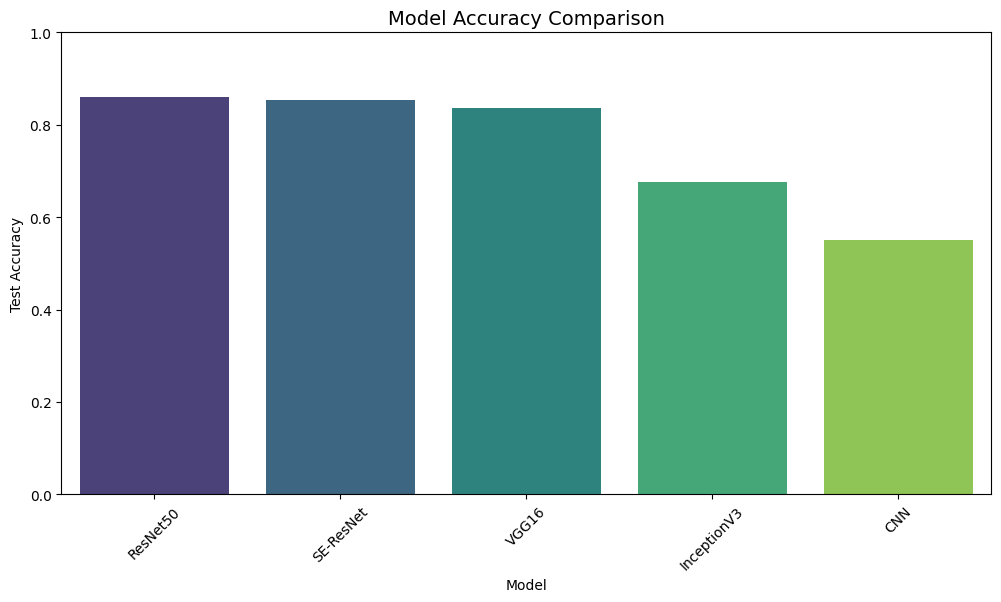

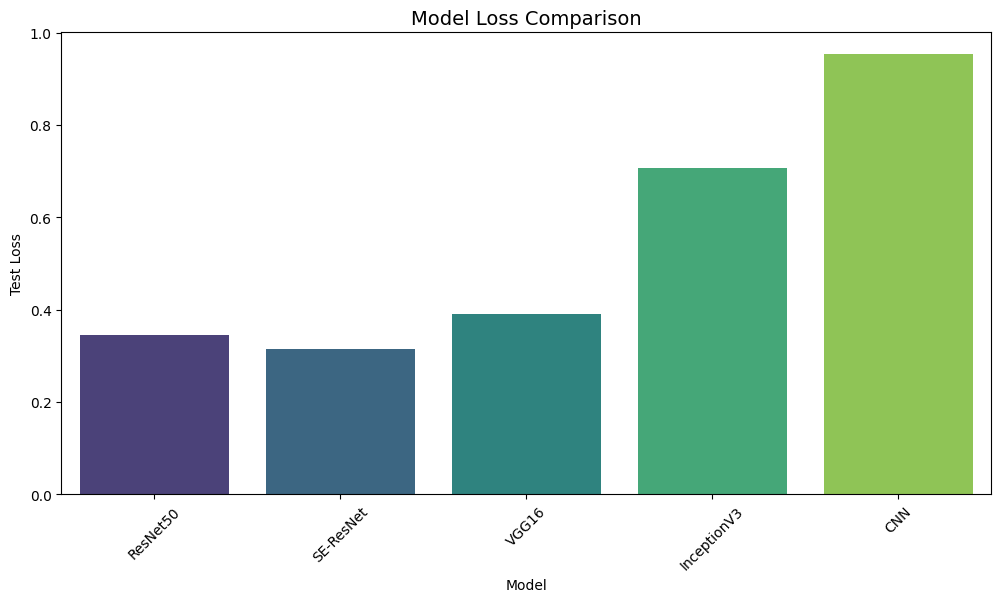

In [ ]:
def evaluate_model(model, test_gen):
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)

    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    cm = confusion_matrix(y_true, y_pred)

    return {
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'classification_report': report,
        'confusion_matrix': cm
    }

results = {}
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    results[name] = evaluate_model(model, test_gen)

performance_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [result['test_accuracy'] for result in results.values()],
    'Test Loss': [result['test_loss'] for result in results.values()]
}).sort_values('Test Accuracy', ascending=False)

print("\nModel Performance Comparison:")
display(performance_df)

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Test Accuracy', data=performance_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Test Loss', data=performance_df, palette='viridis')
plt.title('Model Loss Comparison', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 11. Training History Visualization

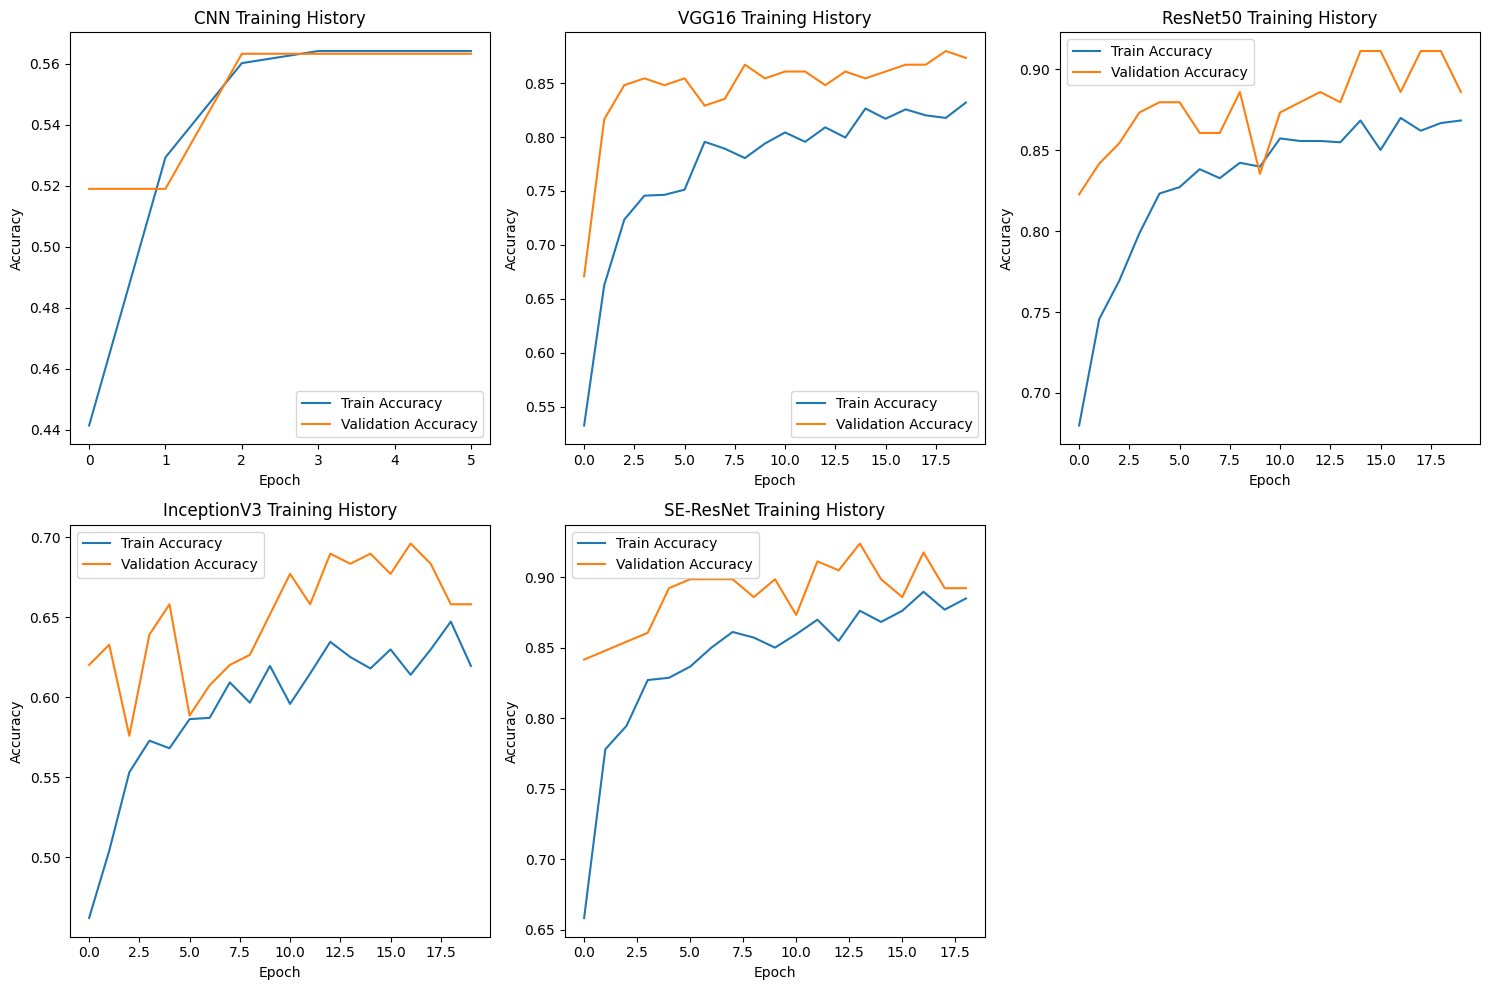

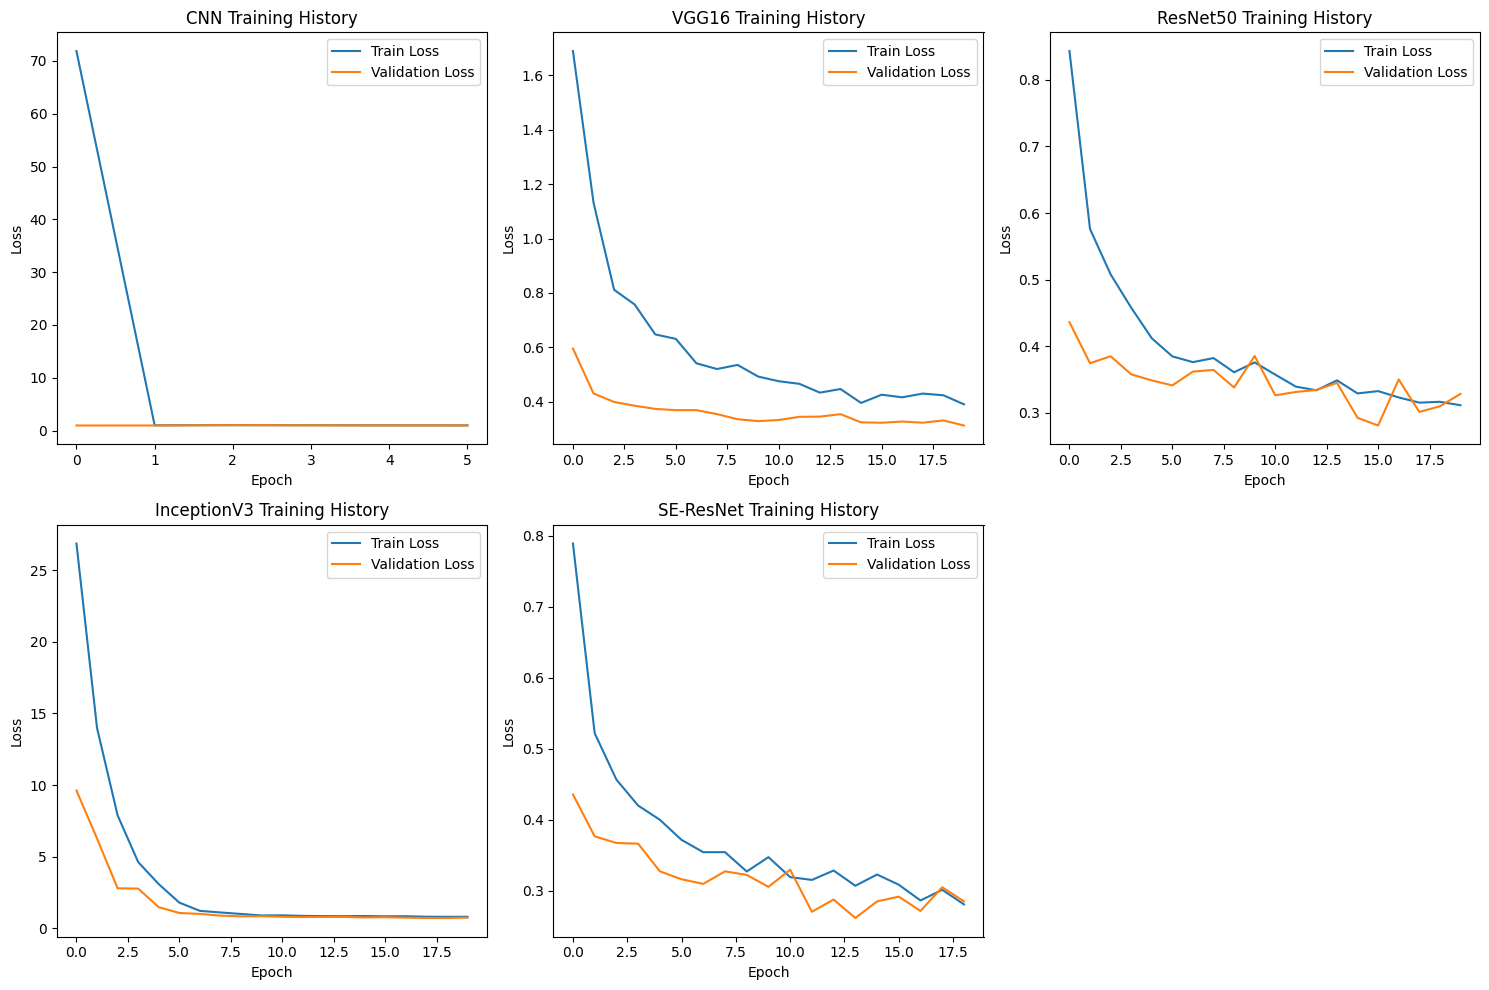

In [ ]:
plt.figure(figsize=(15, 10))
for i, (name, history) in enumerate(histories.items()):
    plt.subplot(2, 3, i+1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{name} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, (name, history) in enumerate(histories.items()):
    plt.subplot(2, 3, i+1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{name} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# 12. Confusion Matrix Visualization

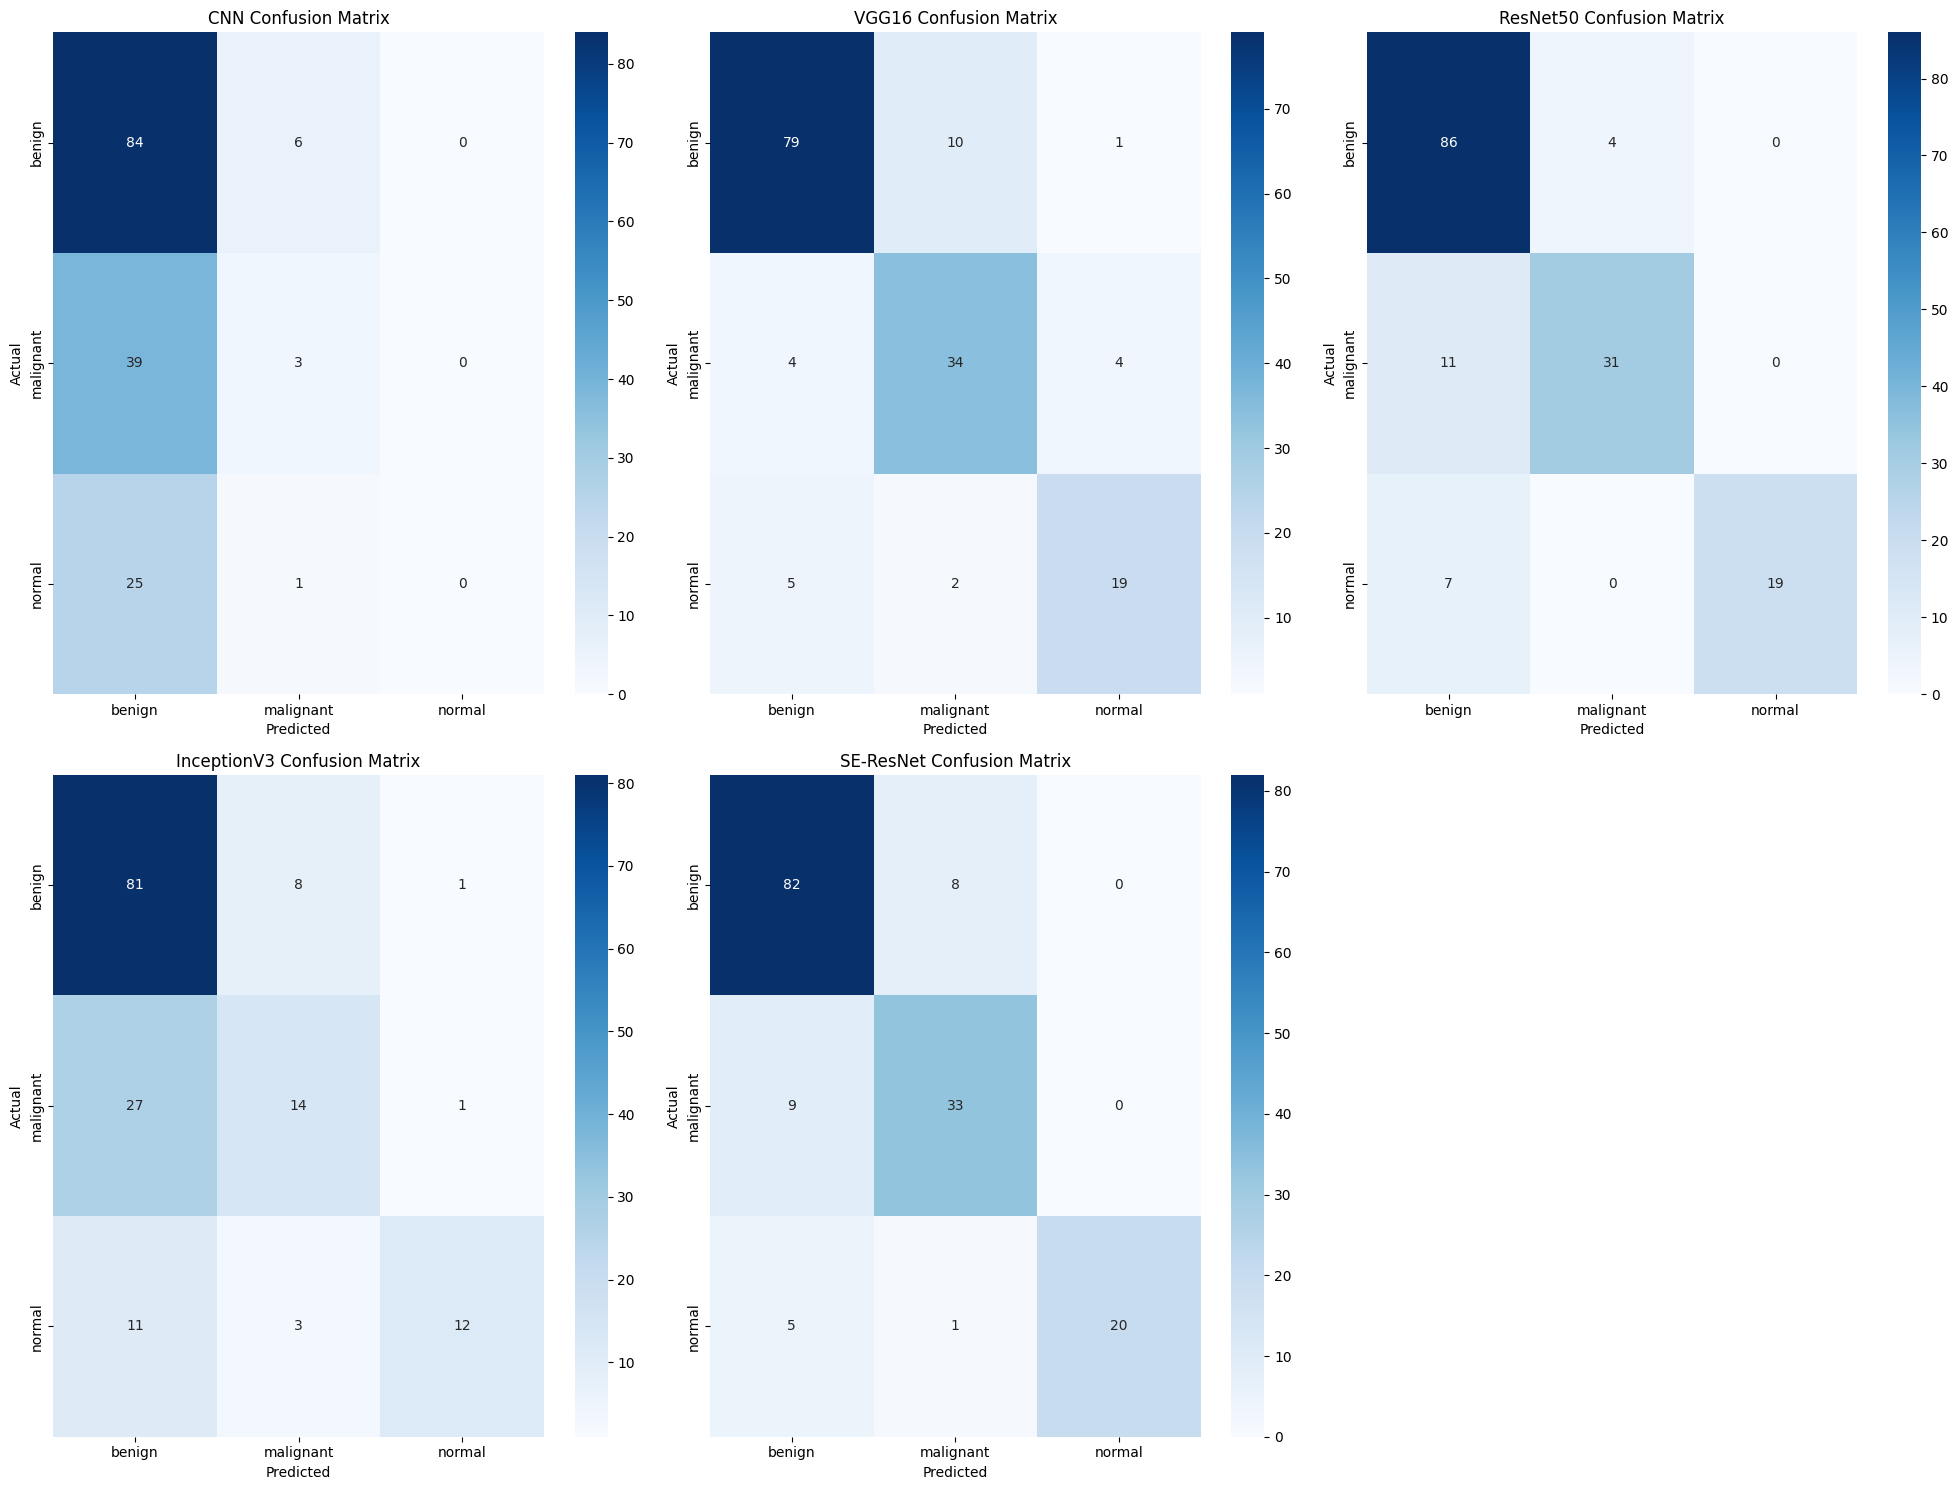

In [ ]:
plt.figure(figsize=(20, 15))
for i, (name, result) in enumerate(results.items()):
    plt.subplot(2, 3, i+1)
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 13. Model Deployment Example


Sample image path: /content/drive/MyDrive/Breast_cancer_assets/Dataset_BUSI_with_GT/benign/benign (341).png
True class: benign

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


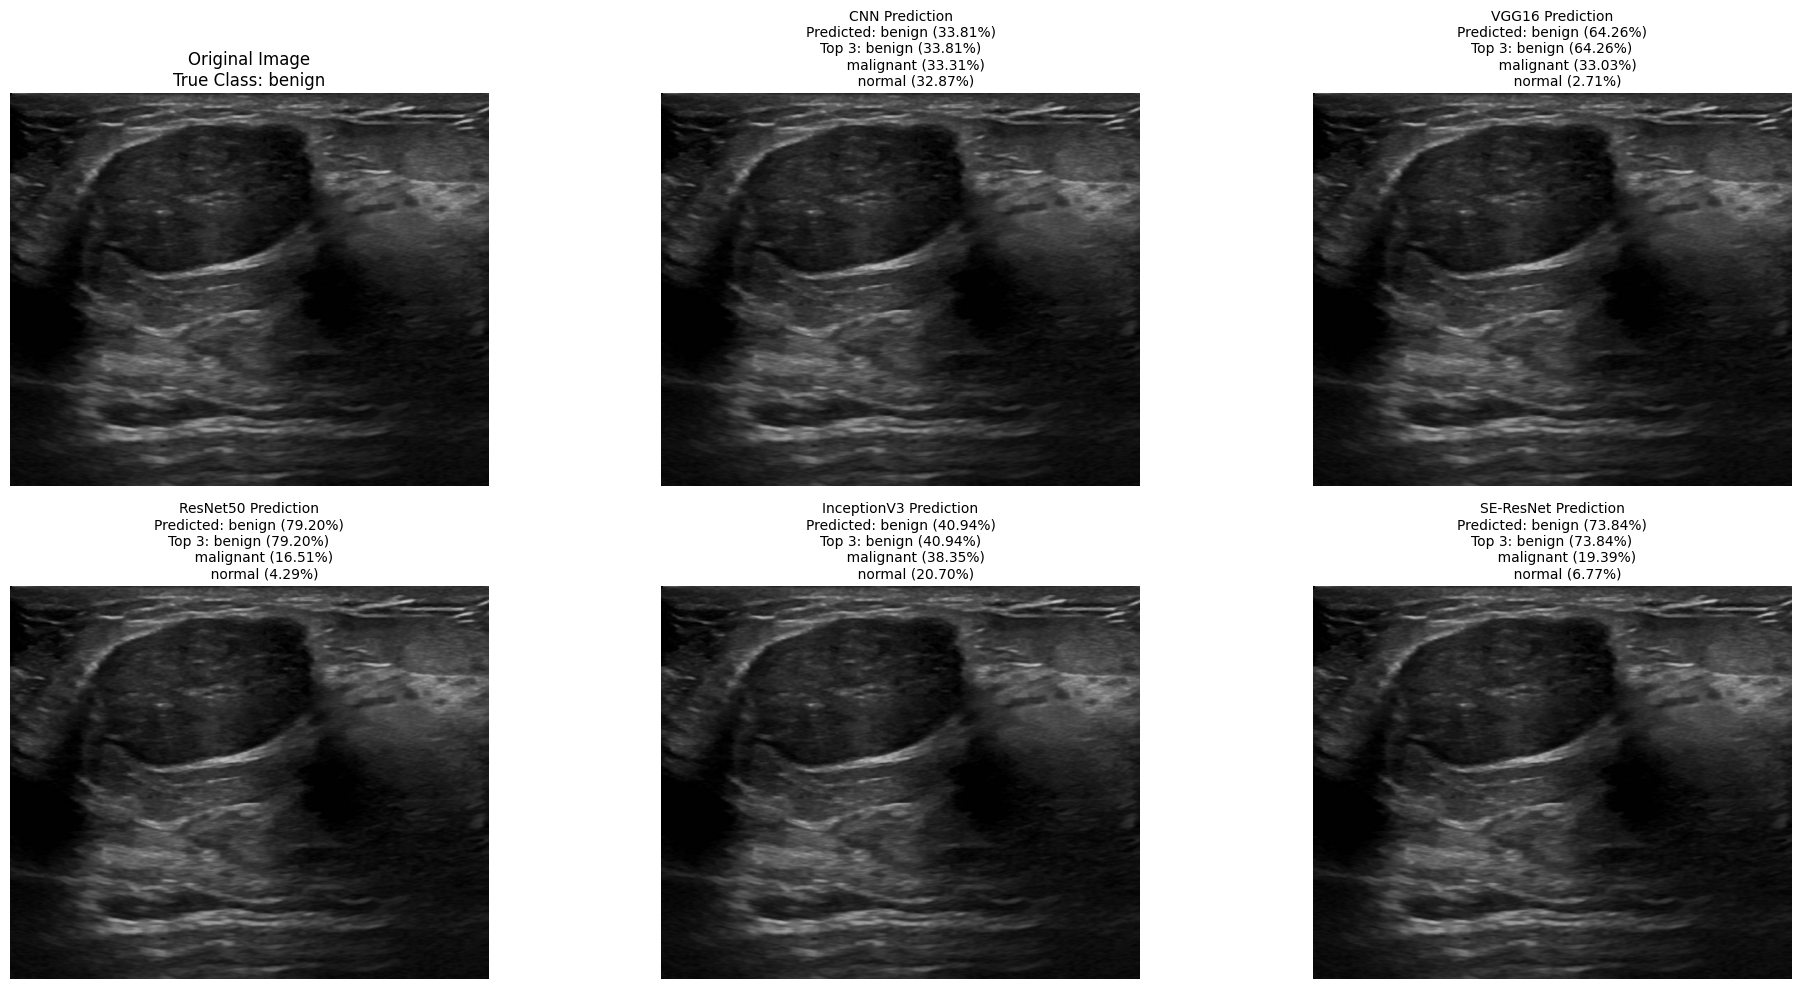

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Detailed Model Predictions Comparison:


,Model,benign,malignant,normal,Prediction,Confidence
0,CNN,33.81%,33.31%,32.87%,benign,33.81%
1,VGG16,64.26%,33.03%,2.71%,benign,64.26%
2,ResNet50,79.20%,16.51%,4.29%,benign,79.20%
3,InceptionV3,40.94%,38.35%,20.70%,benign,40.94%
4,SE-ResNet,73.84%,19.39%,6.77%,benign,73.84%


In [ ]:
sample_image = test_df.iloc[0]['filepaths']
true_class = test_df.iloc[0]['labels']

print(f"\nSample image path: {sample_image}")
print(f"True class: {true_class}\n")

plt.figure(figsize=(20, 10))

img = tf.keras.preprocessing.image.load_img(sample_image)
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title(f"Original Image\nTrue Class: {true_class}", fontsize=12)
plt.axis('off')

for i, (model_name, model) in enumerate(models.items(), start=2):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.image.resize(img_array, img_size)
    img_array = tf.expand_dims(img_array, 0)
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

    preds = model.predict(img_array)
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)

    top3_indices = np.argsort(preds[0])[-3:][::-1]
    top3_classes = [class_names[i] for i in top3_indices]
    top3_confs = [preds[0][i] for i in top3_indices]

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(
        f"{model_name} Prediction\n"
        f"Predicted: {pred_class} ({confidence:.2%})\n"
        f"Top 3: {top3_classes[0]} ({top3_confs[0]:.2%})\n"
        f"       {top3_classes[1]} ({top3_confs[1]:.2%})\n"
        f"       {top3_classes[2]} ({top3_confs[2]:.2%})",
        fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

comparison_data = []
for model_name, model in models.items():
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.image.resize(img_array, img_size)
    img_array = tf.expand_dims(img_array, 0)
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

    preds = model.predict(img_array)

    row = {'Model': model_name}
    for i, class_name in enumerate(class_names):
        row[class_name] = f"{preds[0][i]:.2%}"
    row['Prediction'] = class_names[np.argmax(preds)]
    row['Confidence'] = f"{np.max(preds):.2%}"

    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df[['Model'] + class_names + ['Prediction', 'Confidence']]

print("\nDetailed Model Predictions Comparison:")
display(comparison_df)